# Getting the Dataset

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
df=pd.read_csv("/kaggle/input/traffic-detection-dataset/02-14-2018.csv")
df.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign


# Exploratory Data Analysis

In [36]:
print(f"Length of the dataset: {len(df)} instances")

Length of the dataset: 1048575 instances


In [37]:
print("information about the dataset: \n")
df.info()

information about the dataset: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1048575 non-null  int64  
 1   Protocol           1048575 non-null  int64  
 2   Timestamp          1048575 non-null  object 
 3   Flow Duration      1048575 non-null  int64  
 4   Tot Fwd Pkts       1048575 non-null  int64  
 5   Tot Bwd Pkts       1048575 non-null  int64  
 6   TotLen Fwd Pkts    1048575 non-null  int64  
 7   TotLen Bwd Pkts    1048575 non-null  int64  
 8   Fwd Pkt Len Max    1048575 non-null  int64  
 9   Fwd Pkt Len Min    1048575 non-null  int64  
 10  Fwd Pkt Len Mean   1048575 non-null  float64
 11  Fwd Pkt Len Std    1048575 non-null  float64
 12  Bwd Pkt Len Max    1048575 non-null  int64  
 13  Bwd Pkt Len Min    1048575 non-null  int64  
 14  Bwd Pkt Len Mean   1048575 non-null  float64
 15 

In [38]:
print("data-types\n")
df.dtypes

data-types



Dst Port           int64
Protocol           int64
Timestamp         object
Flow Duration      int64
Tot Fwd Pkts       int64
                  ...   
Idle Mean        float64
Idle Std         float64
Idle Max           int64
Idle Min           int64
Label             object
Length: 80, dtype: object

In [39]:
print("dataset columns : \n")
df.columns

dataset columns : 



Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
      

In [40]:
print("unique values in the final column")
df['Label'].unique()

unique values in the final column


array(['Benign', 'FTP-BruteForce', 'SSH-Bruteforce'], dtype=object)

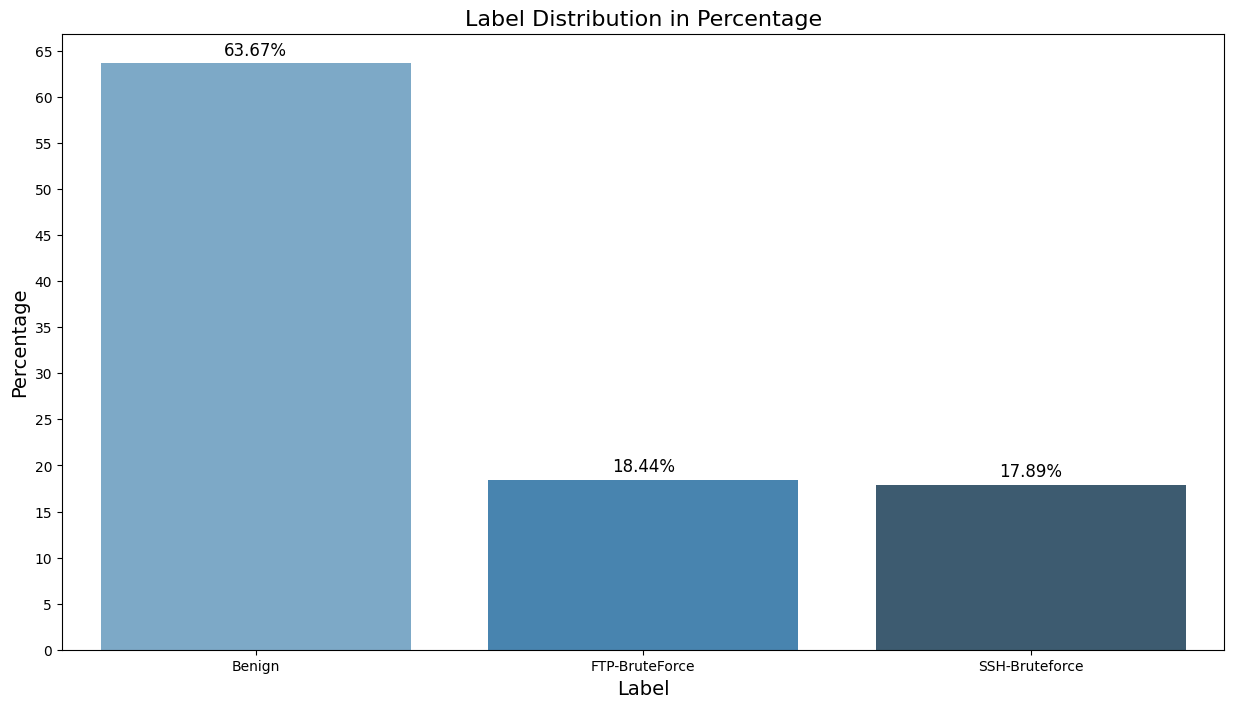

In [41]:
# Set figure size
plt.figure(figsize=(15, 8))
# Set the y-axis ticks (percentage scale)
plt.yticks(np.arange(0, 101, 5))
# Calculate percentages manually for the 'Label' column
label_counts = df["Label"].value_counts(normalize=True) * 100  # Convert counts to percentages
# Create a bar plot using seaborn
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette="Blues_d")
# Add percentage labels on the bars
ax.bar_label(ax.containers[0], fmt="%.2f%%", label_type="edge", fontsize=12, padding=3)
# Set labels and title
plt.xlabel("Label", fontsize=14)
plt.ylabel("Percentage", fontsize=14)
plt.title("Label Distribution in Percentage", fontsize=16)
# Display the plot
plt.show()

# Data Cleaning

In [42]:
df = df.drop(columns=["Timestamp", "Dst Port"])

In [43]:
df.head()

,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,112641719,3,0,0,0,0,0,0.000000,0.000000,...,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,112641466,3,0,0,0,0,0,0.000000,0.000000,...,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,112638623,3,0,0,0,0,0,0.000000,0.000000,...,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,6,6453966,15,10,1239,2273,744,0,82.600000,196.741237,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
4,6,8804066,14,11,1143,2209,744,0,81.642857,203.745545,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign


In [44]:
df['Label'].unique()

array(['Benign', 'FTP-BruteForce', 'SSH-Bruteforce'], dtype=object)

# Get Dummies

In [45]:
df = df.astype({"Protocol": str}) # Change the column data type to string
df["Protocol"].unique()

array(['0', '6', '17'], dtype=object)

In [46]:
df = pd.get_dummies(df, columns=['Protocol'], drop_first=True)

# Checking Null Values

In [47]:
print("null values in dataset:")
df.isna().sum().sum()

null values in dataset:


2277

In [48]:
reduced_df = df.dropna()

In [49]:
print("after removing all the null values:")
reduced_df .shape

after removing all the null values:


(1046298, 79)

In [50]:
print("checking null values after removing them: ")
reduced_df .isna().sum().sum()

checking null values after removing them: 


0

# Further EDA

In [51]:
reduced_df["Label"].value_counts()

Label
Benign            665355
FTP-BruteForce    193354
SSH-Bruteforce    187589
Name: count, dtype: int64

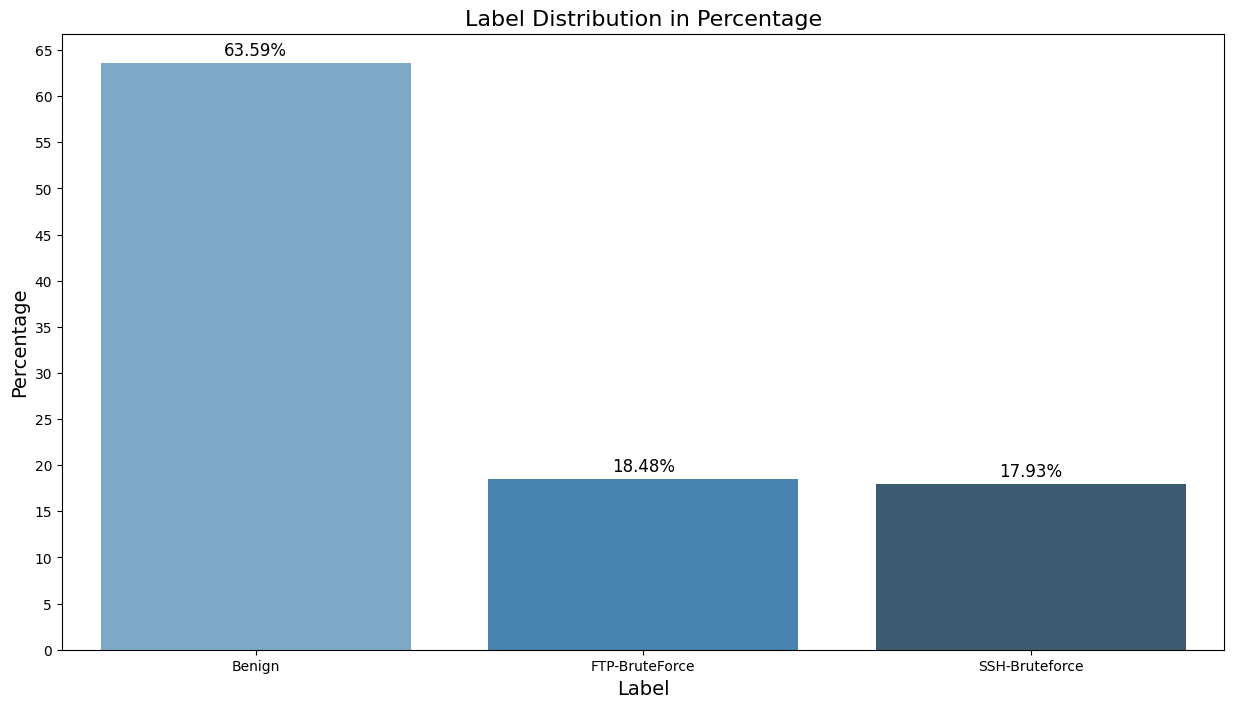

In [52]:
# Set figure size
plt.figure(figsize=(15, 8))
# Set the y-axis ticks (percentage scale)
plt.yticks(np.arange(0, 101, 5))
# Calculate percentages manually for the 'Label' column
label_counts = reduced_df["Label"].value_counts(normalize=True) * 100  # Convert counts to percentages
# Create a bar plot using seaborn
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette="Blues_d")
# Add percentage labels on the bars
ax.bar_label(ax.containers[0], fmt="%.2f%%", label_type="edge", fontsize=12, padding=3)
# Set labels and title
plt.xlabel("Label", fontsize=14)
plt.ylabel("Percentage", fontsize=14)
plt.title("Label Distribution in Percentage", fontsize=16)
# Display the plot
plt.show()

# Label and Feature Encoding

In [53]:
reduced_df['Label'].dtype

dtype('O')

In [54]:
from sklearn.preprocessing import LabelEncoder
l = LabelEncoder()
reduced_df.loc[:, 'Label'] = l.fit_transform(reduced_df['Label'])
reduced_df['Label'].unique()

array([0, 1, 2], dtype=object)

In [55]:
reduced_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1046298 entries, 0 to 1048574
Data columns (total 79 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Flow Duration      1046298 non-null  int64  
 1   Tot Fwd Pkts       1046298 non-null  int64  
 2   Tot Bwd Pkts       1046298 non-null  int64  
 3   TotLen Fwd Pkts    1046298 non-null  int64  
 4   TotLen Bwd Pkts    1046298 non-null  int64  
 5   Fwd Pkt Len Max    1046298 non-null  int64  
 6   Fwd Pkt Len Min    1046298 non-null  int64  
 7   Fwd Pkt Len Mean   1046298 non-null  float64
 8   Fwd Pkt Len Std    1046298 non-null  float64
 9   Bwd Pkt Len Max    1046298 non-null  int64  
 10  Bwd Pkt Len Min    1046298 non-null  int64  
 11  Bwd Pkt Len Mean   1046298 non-null  float64
 12  Bwd Pkt Len Std    1046298 non-null  float64
 13  Flow Byts/s        1046298 non-null  float64
 14  Flow Pkts/s        1046298 non-null  float64
 15  Flow IAT Mean      1046298 non-null  

In [56]:
print("columns with string names:")
string_columns = []
for column in df.columns:
    if reduced_df[column].dtype == 'object':
        string_columns.append(column)
# Print columns containing string values
print("Columns containing string values:")
print(string_columns)

columns with string names:
Columns containing string values:
['Label']


# Removing Negative Values and Removing Duplicates

In [57]:
reduced_df = reduced_df[reduced_df.ge(0).all(axis=1)]

In [58]:
# counting duplicates
print(f"Number of duplicates is: {reduced_df.duplicated().sum().sum()}")

Number of duplicates is: 308259


In [59]:
# removing duplicates
reduced_df = reduced_df.drop_duplicates(ignore_index=True)

In [60]:
# total duplicates now
reduced_df.duplicated().sum().sum()

0

In [61]:
reduced_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392940 entries, 0 to 392939
Data columns (total 79 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Flow Duration      392940 non-null  int64  
 1   Tot Fwd Pkts       392940 non-null  int64  
 2   Tot Bwd Pkts       392940 non-null  int64  
 3   TotLen Fwd Pkts    392940 non-null  int64  
 4   TotLen Bwd Pkts    392940 non-null  int64  
 5   Fwd Pkt Len Max    392940 non-null  int64  
 6   Fwd Pkt Len Min    392940 non-null  int64  
 7   Fwd Pkt Len Mean   392940 non-null  float64
 8   Fwd Pkt Len Std    392940 non-null  float64
 9   Bwd Pkt Len Max    392940 non-null  int64  
 10  Bwd Pkt Len Min    392940 non-null  int64  
 11  Bwd Pkt Len Mean   392940 non-null  float64
 12  Bwd Pkt Len Std    392940 non-null  float64
 13  Flow Byts/s        392940 non-null  float64
 14  Flow Pkts/s        392940 non-null  float64
 15  Flow IAT Mean      392940 non-null  float64
 16  Fl

In [62]:
print("entries before vs after")
len(df),len(reduced_df)

entries before vs after


(1048575, 392940)

# Data Transformation

In [63]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Ensure reduced_df is a numeric DataFrame
reduced_df = reduced_df.apply(pd.to_numeric, errors='coerce')

# Check for any infinite values in the first 78 columns
print("Checking for infinite values in the first 78 columns:")
print(np.isinf(reduced_df.iloc[:, :78]).sum())

# Replace infinite values with NaN
reduced_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with the median of each column
reduced_df.fillna(reduced_df.median(), inplace=True)

# Normalize the features (first 78 columns) using MinMaxScaler
scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(reduced_df.iloc[:, :78])

# Create a new DataFrame with normalized features
normalized_dataset = pd.DataFrame(normalized_features, columns=reduced_df.columns[:78])

# Add the 'Label' column to the normalized dataset
normalized_dataset["Label"] = reduced_df["Label"].values

Checking for infinite values in the first 78 columns:
Flow Duration      0
Tot Fwd Pkts       0
Tot Bwd Pkts       0
TotLen Fwd Pkts    0
TotLen Bwd Pkts    0
                  ..
Idle Std           0
Idle Max           0
Idle Min           0
Label              0
Protocol_17        0
Length: 78, dtype: int64


In [64]:
normalized_dataset.head()

,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Protocol_17
0,0.053783,0.002738,0.000979,0.000144,0.000170,0.011546,0.0,0.007364,0.012483,0.668493,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
1,0.073367,0.002542,0.001087,0.000133,0.000165,0.011546,0.0,0.007278,0.012927,0.668493,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
2,0.058245,0.002933,0.001196,0.000144,0.000170,0.011546,0.0,0.006904,0.012108,0.668493,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
3,0.003971,0.000782,0.000217,0.000025,0.000035,0.003274,0.0,0.003762,0.005987,0.317123,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
4,0.003959,0.000782,0.000217,0.000026,0.000035,0.003414,0.0,0.003923,0.006242,0.323288,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0


## Data Splitting

In [65]:
y = normalized_dataset['Label']
X = normalized_dataset.drop(columns = ['Label'])

## Feature Selection


Selected Features and Their Scores:
          Feature        Score
 Fwd Seg Size Min 5.311517e+06
Fwd Act Data Pkts 1.772815e+05
Init Fwd Win Byts 1.490934e+05
  Fwd Pkt Len Max 2.565495e+04
Init Bwd Win Byts 2.494333e+04
    Flow Duration 1.390019e+04
      Fwd IAT Tot 1.258014e+04
     Fwd IAT Mean 1.219439e+04
      Bwd IAT Tot 1.204401e+04
      Bwd IAT Std 9.880556e+03
     Flow IAT Max 9.666419e+03
     Bwd IAT Mean 9.599174e+03
     Flow IAT Std 9.406289e+03
      Bwd IAT Max 8.588885e+03
      Fwd IAT Std 8.577219e+03
      Fwd IAT Max 8.236027e+03
     RST Flag Cnt 7.590641e+03
     ECE Flag Cnt 7.590641e+03
    Flow IAT Mean 7.036807e+03
         Idle Max 6.897600e+03
        Idle Mean 6.840018e+03
 Bwd Pkt Len Mean 6.747326e+03
 Bwd Seg Size Avg 6.747326e+03
         Idle Min 6.394682e+03
     PSH Flag Cnt 6.189825e+03


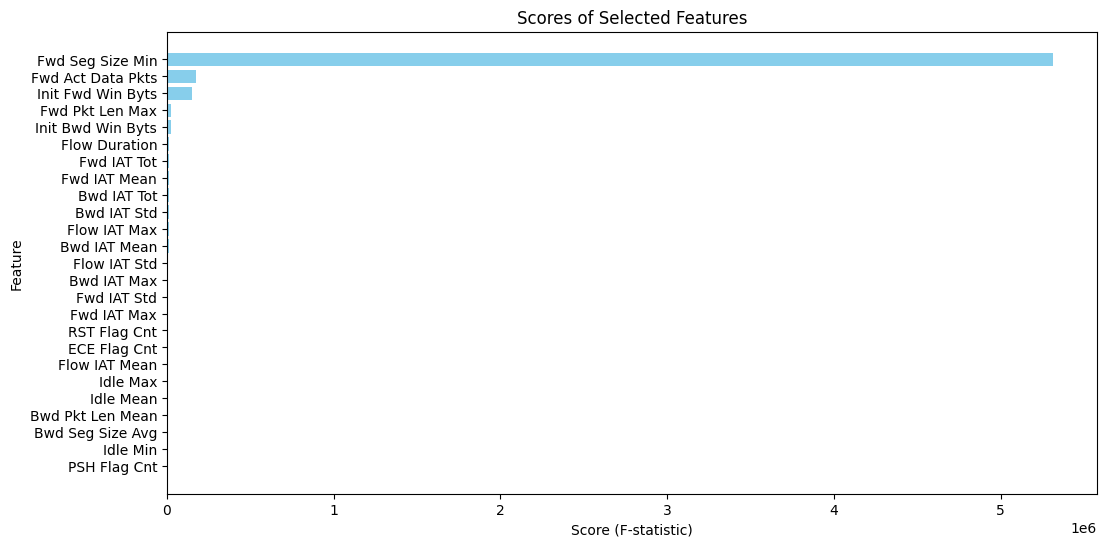

In [66]:
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Select the top 25 features using SelectKBest
selector = SelectKBest(score_func=f_classif, k=25)
selector.fit(X, y)

# Get selected feature names and their scores
selected_features = X.columns[selector.get_support()]
scores = selector.scores_[selector.get_support()]

# Create a DataFrame for better readability
feature_scores = pd.DataFrame({'Feature': selected_features, 'Score': scores})
feature_scores = feature_scores.sort_values(by='Score', ascending=False)

# Print structured output
print("\nSelected Features and Their Scores:")
print(feature_scores.to_string(index=False))

# Plot feature scores
plt.figure(figsize=(12, 6))
plt.barh(feature_scores['Feature'], feature_scores['Score'], color='skyblue')
plt.xlabel('Score (F-statistic)')
plt.ylabel('Feature')
plt.title('Scores of Selected Features')
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.show()


In [67]:
# Dataset after feature selection 
df_c = pd.concat([X_selected, y], axis=1)
df_c.head()

,Flow Duration,Fwd Pkt Len Max,Bwd Pkt Len Mean,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,...,ECE Flag Cnt,Bwd Seg Size Avg,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Idle Mean,Idle Max,Idle Min,Label
0,0.053783,0.011546,0.155766,0.004503,0.002941,0.005633,0.053783,0.007681,0.002060,0.005633,...,0.0,0.155766,1.000000,0.003555,0.00582,0.428571,0.0,0.0,0.0,0
1,0.073367,0.011546,0.137618,0.006142,0.006078,0.016118,0.073367,0.011285,0.008910,0.016118,...,0.0,0.137618,0.088624,0.003555,0.00582,0.428571,0.0,0.0,0.0,0
2,0.058245,0.011546,0.129805,0.004334,0.003467,0.007951,0.058245,0.007764,0.004089,0.007951,...,0.0,0.129805,0.088624,0.003571,0.00679,0.000000,0.0,0.0,0.0,0
3,0.003971,0.003274,0.105763,0.001140,0.001377,0.001987,0.003971,0.001985,0.002299,0.001993,...,0.0,0.105763,0.222782,0.003342,0.00097,0.428571,0.0,0.0,0.0,0
4,0.003959,0.003414,0.107819,0.001136,0.001376,0.001985,0.003959,0.001979,0.002294,0.001988,...,0.0,0.107819,0.222782,0.003342,0.00097,0.428571,0.0,0.0,0.0,0


# Correlation Matrix

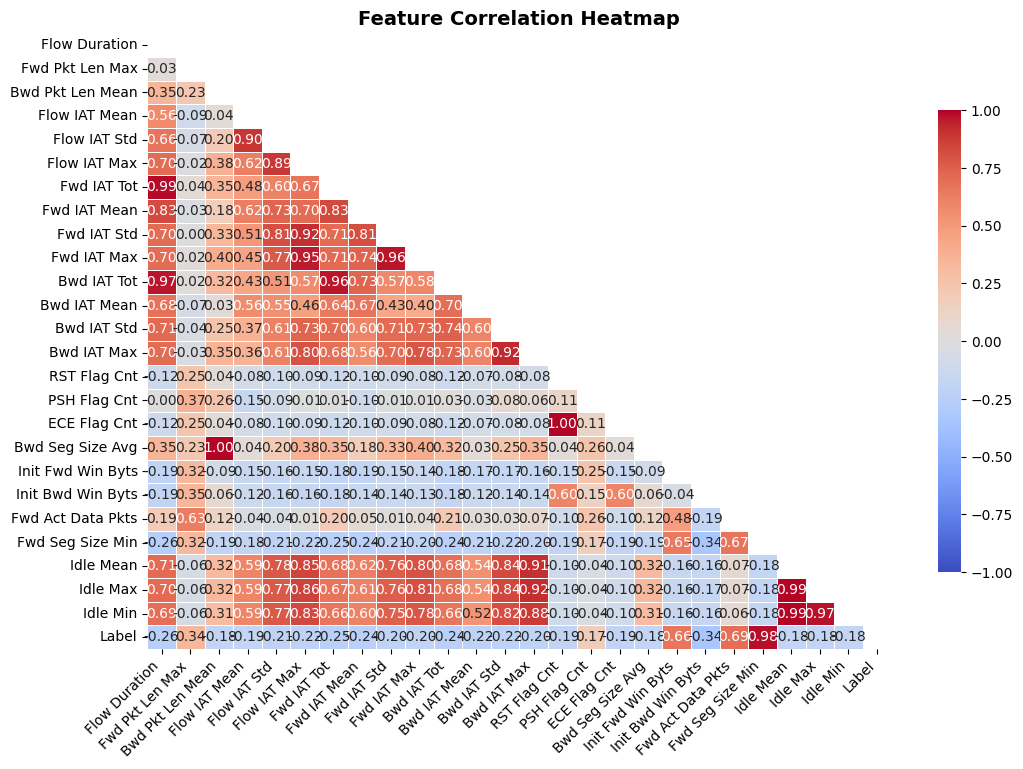

In [68]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = df_c.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Use a more readable colormap
cmap = sns.color_palette("coolwarm", as_cmap=True)

# Draw the heatmap
sns.heatmap(corr, mask=mask, cmap=cmap, annot=True, fmt=".2f", linewidths=0.5, 
            annot_kws={"size": 10}, cbar_kws={"shrink": 0.75}, vmin=-1, vmax=1)

# Improve readability
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.show()


# Classification

In [69]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the pipeline
pipe = Pipeline([
    ('scaler', MinMaxScaler()),  # MinMaxScaler for feature scaling
    ('feature_selection', SelectKBest(score_func=f_classif, k='all')),  # Select all features
    ('reducer', PCA(n_components=0.9)),  # Retain 90% variance
    ('classifier', RandomForestClassifier(random_state=0))  # Random Forest model
])

# Fit the pipeline to the training data
pipe.fit(X_train, y_train)

# Print explained variance ratio
print("Explained Variance Ratio:", pipe['reducer'].explained_variance_ratio_)

# Evaluate on test set
test_accuracy = pipe.score(X_test, y_test)

# Print results
print(f'Test set accuracy: {test_accuracy:.4%}')

Explained Variance Ratio: [0.28732637 0.2799467  0.16475683 0.0685383  0.05461637 0.03605973
 0.03469662]
Test set accuracy: 99.9949%
